In [1]:
import os
import sys
import csv
import glob
import joblib
import datasets
import datetime
import numpy as np
import pandas as pd
from pathlib import Path
from pprint import pprint
import time

from huggingface_hub import snapshot_download

from sklearn.ensemble import RandomForestClassifier as skRF
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.inspection import permutation_importance

import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from osgeo import gdalconst
from osgeo import gdal
import folium
from folium import plugins
import folium_helper

plt.style.use('fivethirtyeight')
warnings.filterwarnings('ignore')
%matplotlib inline


/Users/jigneshshah/miniforge3/envs/python_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import inspect
print(inspect.getsource(folium_helper.get_bounds))
print(folium_helper.__file__)

def get_bounds(tiff_3857):
    with rio.open(tiff_3857) as src:
        #src_crs = src.crs['init'].upper()
        src_crs = src.crs
        min_lon, min_lat, max_lon, max_lat = src.bounds
    bounds_orig = [[min_lat, min_lon], [max_lat, max_lon]]
    bounds = []
    #dst_crs = 'EPSG:4326'
    dst_crs = 4326
    for item in bounds_orig:   
        #converting to lat/lon
        lat = item[0]
        lon = item[1]
        #proj = Transformer.from_crs(int(src_crs.split(":")[1]), int(dst_crs.split(":")[1]), always_xy=True)
        proj = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
        lon_n, lat_n = proj.transform(lon, lat)
        bounds.append([lat_n, lon_n])
    center_lon = bounds[0][1] + (bounds[1][1] - bounds[0][1])/2
    center_lat = bounds[0][0] + (bounds[1][0] - bounds[0][0])/2
    return {'bounds': bounds, 'center': (center_lon, center_lat)}

/Users/jigneshshah/Desktop/ML_related/ml_models_remote_sensing/folium_helper.py


In [3]:
# directory where we will output figures
FIGURE_OUTPUT_DIR = "output"

# directory where we will output raster
RASTER_OUTPUT_DIR = "output"

# directory where we will output our models
MODEL_OUTPUT_DIR = "models"

DATASET_URL = "nasa-cisto-data-science-group/modis-lake-powell-toy-dataset"

TEST_RATIO  = 0.2

RANDOM_STATE = 42

LABEL_NAME = "water"

DATA_TYPE = np.int16

# Columns that are offset, years, julian days, etc (always need to be dropped)
offsets_indexes = ["x_offset", "y_offset", "year", "julian_day", "titleID"]

# columns not needed for training
colsToDrop = ["x_offset", "y_offset", "year", "julian_day"]


colsToDropTraining = colsToDrop.copy()
colsToDropTraining.extend(offsets_indexes)

# columns used as features during training
v_names = ['sur_refl_b01_1','sur_refl_b02_1','sur_refl_b03_1',
           'sur_refl_b04_1','sur_refl_b05_1','sur_refl_b06_1',
           'sur_refl_b07_1','ndvi','ndwi1','ndwi2']

In [4]:
os.getcwd()
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_OUTPUT_DIR, exist_ok=True)

#### Data Loading
Extract a tabular dataset from MODIS GeoTiFF files
- Read in data to a DataFrame
- Drop uncesary columns
- Splits into Xs and ys

In [5]:
%%time
train_dataset = pd.DataFrame(datasets.load_dataset(DATASET_URL, split="train"))
test_dataset = pd.DataFrame(datasets.load_dataset(DATASET_URL, split="test"))


CPU times: user 146 ms, sys: 37.2 ms, total: 183 ms
Wall time: 2.48 s


In [6]:
X_train, y_train = train_dataset.drop(["water"], axis=1), train_dataset["water"]
X_test, y_test = test_dataset.drop(["water"], axis=1), test_dataset["water"]

X_train.shape, X_test.shape

((800, 10), (200, 10))

In [7]:
y_train.value_counts(), y_test.value_counts()

(water
 1    405
 0    395
 Name: count, dtype: int64,
 water
 0    105
 1     95
 Name: count, dtype: int64)

#### KFOLD cross-validation

In [8]:
kf = KFold(n_splits=5)
kf.get_n_splits(X_train)

5

In [9]:
def output_intresting_idx(df, column, threshold, greaterThan = True):
    dfToReturn = df[df[column] > threshold] if \
        greaterThan else df[df[column] < threshold]
    return dfToReturn

In [10]:
output_intresting_idx(X_train, "ndvi", 2000)

,sur_refl_b01_1,sur_refl_b02_1,sur_refl_b03_1,sur_refl_b04_1,sur_refl_b05_1,sur_refl_b06_1,sur_refl_b07_1,ndvi,ndwi1,ndwi2
0,2031,3113,776,1200,3626,3480,2957,2103,-556,257
2,1609,2615,797,1000,2143,1708,1107,2381,2098,4051
12,750,2293,453,720,2549,2321,1538,5070,-60,1970
25,1216,1982,415,619,1642,1406,939,2395,1700,3570
32,592,1591,322,483,1564,1192,719,4576,1433,3774
...,...,...,...,...,...,...,...,...,...,...
765,319,1479,108,340,1153,536,309,6451,4679,6543
768,945,1756,562,819,2051,1949,1391,3002,-520,1159
772,870,1891,564,822,2535,2434,1834,3697,-1255,153
780,647,1622,425,627,1760,1429,1025,4297,632,2255


In [11]:
hyperparameters = {'n_estimators': 400, 
                   'criterion':'gini', 
                   'max_depth':None, 
                   'min_samples_split':2, 
                   'min_samples_leaf':1, 
                   'min_weight_fraction_leaf':0.0, 
                   'max_features':'sqrt', 
                   'max_leaf_nodes':None, 
                   'min_impurity_decrease':0.0, 
                   'bootstrap':True, 
                   'oob_score':False, 
                   'n_jobs':-1, 
                   'random_state':42, 
                   'verbose':0, 
                   'warm_start':True, 
                   'class_weight':None, 
                   'ccp_alpha':0.0, 
                   'max_samples':None
                  }

In [12]:
classifier = skRF(**hyperparameters)

In [13]:
%%time
bestModel = None
bestModelScore = 0
scores = []
n = 0
for trainIdx, testIdx in kf.split(X_train):
    n += 1
    print(n)
    print(f"Train {trainIdx.max()}, Test {testIdx.max()}")
    X_train_valid, X_test_valid = X_train.iloc[trainIdx], X_train.iloc[testIdx]
    y_train_valid, y_test_valid = y_train.iloc[trainIdx], y_train.iloc[testIdx]
    print("Fitting Model")
    st = time.time()
    classifier.fit(X_train_valid, y_train_valid)
    et = time.time()
    print(f"Time to fit model: {et-st}")
    print("Getting score")
    score = classifier.score(X_test_valid, y_test_valid)
    print("Checking score")
    if score>=bestModelScore:
        bestModelScore = score
        print(f"Training accuracy score:{score}")
        bestModel = classifier
    print("Predicting for test set")
    test_predictions = classifier.predict(X_test_valid)
    print(classification_report(y_test_valid, test_predictions))
    print(f"Score : {score}")
    scores.append(score)
    del test_predictions, score

1
Train 799, Test 159
Fitting Model
Time to fit model: 0.2316880226135254
Getting score
Checking score
Training accuracy score:0.96875
Predicting for test set
              precision    recall  f1-score   support

           0       0.97      0.96      0.97        78
           1       0.96      0.98      0.97        82

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160

Score : 0.96875
2
Train 799, Test 319
Fitting Model
Time to fit model: 0.0006248950958251953
Getting score
Checking score
Training accuracy score:1.0
Predicting for test set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        85

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160

Score : 1.0
3

In [14]:
scoreAvg = np.asarray(scores).mean()
print("Average accuracy score : {}".format(scoreAvg))
print("Best accuracy score : {}".format(bestModelScore))

Average accuracy score : 0.99375
Best accuracy score : 1.0


In [15]:
classifier = skRF(**hyperparameters)

In [16]:
%%time
classifier.fit(X_train, y_train)


CPU times: user 351 ms, sys: 101 ms, total: 453 ms
Wall time: 233 ms


,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
score = classifier.score(X_test, y_test)
print("Average accuracy score : {}".format(score))


Average accuracy score : 0.99


### Model testing and training/testing data validation

In [18]:
classifier = bestModel
score = classifier.score(X_test, y_test)
score = round(score, 3)
score

0.98

In [19]:
train_predictions = classifier.predict(X_train)
test_predictions = classifier.predict(X_test)
prediction_probs = classifier.predict_proba(X_test)



In [20]:
print(f"Shape when preidicting the probablities {prediction_probs.shape}")
print(f"Shape when normal prediction {test_predictions.shape}")


Shape when preidicting the probablities (200, 2)
Shape when normal prediction (200,)


In [21]:
prediction_probs

array([[0.    , 1.    ],
       [0.0025, 0.9975],
       [0.0175, 0.9825],
       [1.    , 0.    ],
       [1.    , 0.    ],
       [0.01  , 0.99  ],
       [0.9925, 0.0075],
       [1.    , 0.    ],
       [0.875 , 0.125 ],
       [1.    , 0.    ],
       [0.3675, 0.6325],
       [0.    , 1.    ],
       [1.    , 0.    ],
       [0.2525, 0.7475],
       [0.0025, 0.9975],
       [0.9875, 0.0125],
       [1.    , 0.    ],
       [0.    , 1.    ],
       [1.    , 0.    ],
       [1.    , 0.    ],
       [0.    , 1.    ],
       [0.    , 1.    ],
       [1.    , 0.    ],
       [0.9975, 0.0025],
       [0.    , 1.    ],
       [0.    , 1.    ],
       [0.0075, 0.9925],
       [1.    , 0.    ],
       [0.05  , 0.95  ],
       [1.    , 0.    ],
       [0.995 , 0.005 ],
       [0.    , 1.    ],
       [1.    , 0.    ],
       [1.    , 0.    ],
       [1.    , 0.    ],
       [1.    , 0.    ],
       [1.    , 0.    ],
       [0.4875, 0.5125],
       [0.    , 1.    ],
       [1.    , 0.    ],


In [22]:
predictionProbabilityList = list()
for i, subbarr in enumerate(prediction_probs):
    predictionProbabilityList.append(subbarr[1]) # Here 1 is becuase predict_proba will give probablity of giving 
predictionProbabilityList = np.asarray(predictionProbabilityList)

Text(0.5, 1.0, 'Distribution of the probablity of predicted values')

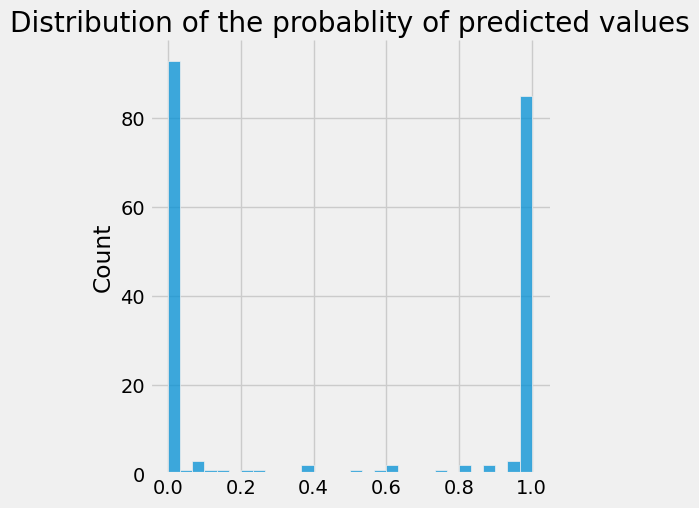

In [23]:
sns.displot(predictionProbabilityList, bins = 30)
plt.title("Distribution of the probablity of predicted values")

In [24]:
test_predictions = test_predictions.astype(np.int32)
y_test_int = y_test.astype(np.int32)

### Additional Metrics


In [25]:
print('Test perfomance')
print('-------------------------------------------------------')
print(classification_report(y_test, test_predictions))
cm = confusion_matrix(y_test_int, test_predictions)
print('Confusion Matrix')
print('-------------------------------------------------------')
print(cm)


Test perfomance
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       105
           1       0.97      0.99      0.98        95

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

Confusion Matrix
-------------------------------------------------------
[[102   3]
 [  1  94]]


### ROC Curve
Map between Fasle Positive Rate vs True Positive Rate
1. TPR = True Positive (TP)/(True Positives (TP) + False Negative (FN))
    1. Out of total positive how many correctly identified as positives -- Here False Negatives are also positive because because they are incorrectly identified as negative
    2. TPR is also called as sensitivity, recall
2. FPR = False Positives (FP)/(False Positives (FP) + True Negatives (TN))
    1. False Positives (FP): actual negatives incorrectly predicted as positives -- (These were actually negative)
    2. True Negatives (TN) : actual negatives correctly predicted as negatives -- (These were actually negative and )
    3. Meansure how often model incorrectly labels negative cases as possible
    4. Out of all actual negative cases, how many did the model wrongly classify as positive
3. Perfect classifier is where TPR = 1 and FPR = 0 (**top left corner**)
4. A random gusser will follow diagonal line (TPR = FPR)
5. **The area under curve (AUC)** summarize the ROC - higher ROC means better overall discrimination overall
6. Sklearn roc_curve gives fpr, tpr and threshold -- In roc_curve you have to give probablities of prediction so roc will select threshold. For example is threshold is 0.5 than everything above 0.5 will be selected as Positive. So when threshold is let say 0.1 then lot of samples will be positives so actual negatives will be classified as positives so **False Positives will increase**. Here now model threshold is so leninent then model will going to catch all positives then **False Negatives (actual positive predicted as negative) will going to decrease** 
7. Let examples - threshold is 0, fpr 1 and tpr 1 - so -- Here threshold 0 if fpr is 1 then all then false positive is going to increase that is why fpr is 1 and when TPR is 1 because False Negatives is 0 that is why TPR is 1


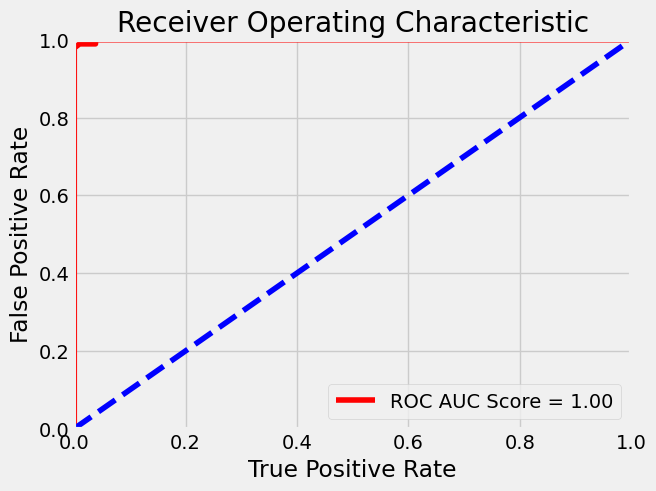

In [26]:
clf = classifier
probs = clf.predict_proba(X_test)
preds = probs[:, 1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.title("Receiver Operating Characteristic")
plt.plot(fpr, tpr, 'red', label = 'ROC AUC Score = %0.2f' % roc_auc)
plt.legend(loc = "lower right")
plt.plot([0,1], [0,1], 'b--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel("True Positive Rate")
plt.ylabel("False Positive Rate")
plt.show()

### Permutation Importance

In [27]:
%%time
permutation_importance_results = permutation_importance(classifier, X = X_test, y = y_test, n_repeats=10, random_state=42)

CPU times: user 1.64 s, sys: 766 ms, total: 2.4 s
Wall time: 2.73 s


In [28]:
score
hyperparameters['n_estimators']

400

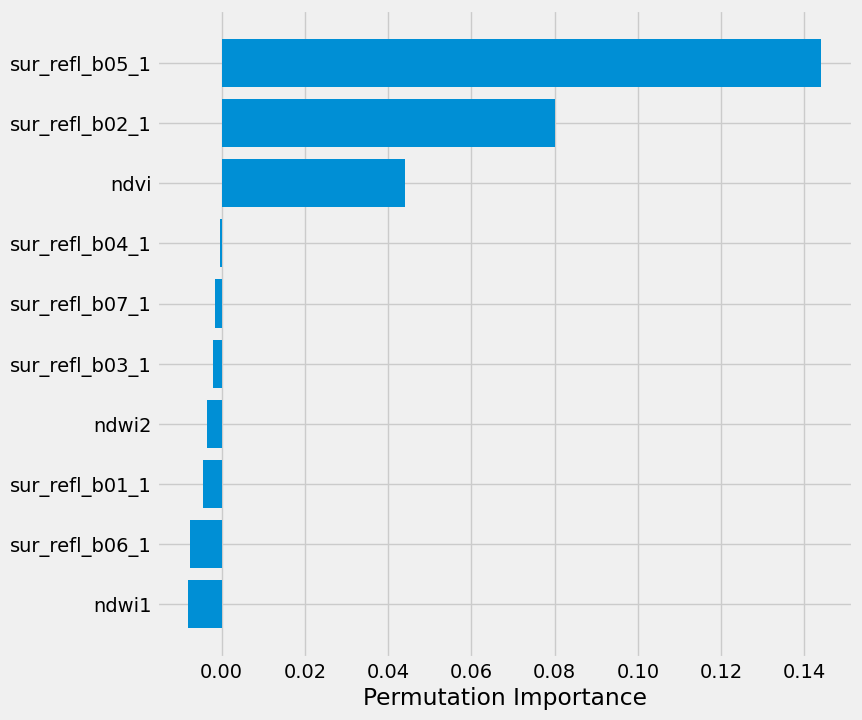

In [29]:
png_save_path = "mw_{}_{}_rf_{}_permutation_importance.png".format(
    score,
    hyperparameters['n_estimators'],
    datetime.datetime.now().strftime('%Y_%m_%d_%H_%M'))
png_save_path = os.path.join(FIGURE_OUTPUT_DIR, png_save_path)
sorted_idx = permutation_importance_results.importances_mean.argsort()
plt.figure(figsize=(8,8))
plt.barh(X_test.columns[sorted_idx], permutation_importance_results.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.savefig(png_save_path)

In [ ]:
png_save_path

In [30]:
del X_train, X_test, y_train, y_test, test_predictions, train_predictions, y_test_int

### Save the model for future use

In [31]:
model_save_path = "mw_{}_{}_{}_2.0.0_tuned_{}.sav".format(score,
                                                          hyperparameters['n_estimators'],
                                                          'cpu',
                                                          datetime.datetime.now().strftime("%Y_%m_%d_%H_%M"))

model_save_path = os.path.join(MODEL_OUTPUT_DIR, model_save_path)
print("Saving model to: {}".format(model_save_path))
joblib.dump(classifier, model_save_path, compress=3)

Saving model to: models/mw_0.98_400_cpu_2.0.0_tuned_2025_11_06_22_02.sav


['models/mw_0.98_400_cpu_2.0.0_tuned_2025_11_06_22_02.sav']

### Raster Inference

#### Data download

In [32]:
powell_dataset = snapshot_download(repo_id=DATASET_URL, allow_patterns="*.tif", repo_type="dataset")

Fetching 11 files: 100%|██████████| 11/11 [00:00<00:00, 61109.06it/s]


Then we can select all individual band TIF images and stack them to form the raster needed as input to the model. Note that you can skip this step if you already have your raster that includes all bands.

In [33]:
fileList = sorted([file for file in glob.glob(os.path.join(powell_dataset, "IL.*.Powell.*.tif")) if "sur_refl" in file])

In [34]:
fileList

['/Users/jigneshshah/.cache/huggingface/hub/datasets--nasa-cisto-data-science-group--modis-lake-powell-toy-dataset/snapshots/e22fb0ce2c73d603ff182183fbfc1476d0032d1d/IL.2001155.Powell.20220871535-sur_refl_b01_1.tif',
 '/Users/jigneshshah/.cache/huggingface/hub/datasets--nasa-cisto-data-science-group--modis-lake-powell-toy-dataset/snapshots/e22fb0ce2c73d603ff182183fbfc1476d0032d1d/IL.2001155.Powell.20220871535-sur_refl_b02_1.tif',
 '/Users/jigneshshah/.cache/huggingface/hub/datasets--nasa-cisto-data-science-group--modis-lake-powell-toy-dataset/snapshots/e22fb0ce2c73d603ff182183fbfc1476d0032d1d/IL.2001155.Powell.20220871535-sur_refl_b03_1.tif',
 '/Users/jigneshshah/.cache/huggingface/hub/datasets--nasa-cisto-data-science-group--modis-lake-powell-toy-dataset/snapshots/e22fb0ce2c73d603ff182183fbfc1476d0032d1d/IL.2001155.Powell.20220871535-sur_refl_b04_1.tif',
 '/Users/jigneshshah/.cache/huggingface/hub/datasets--nasa-cisto-data-science-group--modis-lake-powell-toy-dataset/snapshots/e22fb0c

Then we can perform some feature engineering on the fly to add some additional column feature such as NDVI, NDWI1, and NDWI2

In [ ]:
def readRastersToArray(fileList):
    """
    This function will perform function
    1. Convert rasters to array as random forest will take array or pandas dataframe as input
    2. GetRasterBand(1) -- Get first band of raster
    3. ReadAsArray() -- Read entire raster band as data into a Numpy array
    4. ravel() - convert 2d array into 1d array 
    """
    rasterProjection = None
    newshp = (1300*1300, 10) # Here 1300 is used because this total number of x and y cells in each image
    img = np.empty(newshp, dtype=np.int16) # Create empty array 
    for i, fileName in enumerate(fileList): 
        ds = gdal.Open(fileName) # Open tif file using gdal
        img[:, i] = ds.GetRasterBand(1).ReadAsArray().astype(np.int16).ravel()
        if i == 0:
            rasterProjection = ds.GetProjection()
        ds = None
    img[:, len(fileList)] = ((img[:, 1] - img[:, 0]) / (img[:, 1] + img[:, 0])) * 10000 # This is I think for NDVI
    img[:, len(fileList)+1] = ((img[:, 1] - img[:, 5]) / (img[:, 1] + img[:, 5])) * 10000 # This is I think for NDWI1
    img[:, len(fileList)+2] = ((img[:, 1] - img[:, 6]) / (img[:, 1] + img[:, 6])) * 10000 # This is I think for NDWI2
    return img, rasterProjection   


In [37]:
ds = gdal.Open(fileList[0])
ds.GetRasterBand(1).ReadAsArray().astype(np.int16).ravel()
ds.GetProjection()

'PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not_specified_based_on_custom_spheroid",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'

In [38]:
%%time
im, rasterProjection = readRastersToArray(fileList)
print("Raster as ndarray")
print(im)
print('{} MB size'.format((im.size*im.itemsize) / 1000000))


Raster as ndarray
[[ 1547  2461   857 ...  2280  -518   510]
 [ 1474  2377   857 ...  2344  -691   337]
 [ 1474  2377   846 ...  2344  -472   623]
 ...
 [ 2358  2979  1028 ...  1163 -1727 -1292]
 [ 2425  3069  1117 ...  1172 -1721 -1216]
 [ 2402  3038  1117 ...  1169 -1770 -1266]]
33.8 MB size
CPU times: user 84.1 ms, sys: 12.6 ms, total: 96.7 ms
Wall time: 95.8 ms


### Data Preparation
Here we convert our raster array into dataframe format to serve as input to the model

In [39]:
raster_dataframe = pd.DataFrame(im, columns=v_names, dtype=np.float32)
raster_dataframe

,sur_refl_b01_1,sur_refl_b02_1,sur_refl_b03_1,sur_refl_b04_1,sur_refl_b05_1,sur_refl_b06_1,sur_refl_b07_1,ndvi,ndwi1,ndwi2
0,1547.0,2461.0,857.0,1256.0,2684.0,2730.0,2222.0,2280.0,-518.0,510.0
1,1474.0,2377.0,857.0,1256.0,2684.0,2730.0,2222.0,2344.0,-691.0,337.0
2,1474.0,2377.0,846.0,1230.0,2630.0,2613.0,2098.0,2344.0,-472.0,623.0
3,1494.0,2461.0,846.0,1230.0,2630.0,2613.0,2098.0,2445.0,-299.0,796.0
4,1494.0,2461.0,846.0,1230.0,2630.0,2613.0,2098.0,2445.0,-299.0,796.0
...,...,...,...,...,...,...,...,...,...,...
1689995,2211.0,2826.0,1080.0,1796.0,3650.0,4266.0,3862.0,1220.0,-2030.0,-1549.0
1689996,2209.0,2801.0,1028.0,1791.0,3633.0,4223.0,3863.0,1181.0,-2024.0,-1593.0
1689997,2358.0,2979.0,1028.0,1791.0,3633.0,4223.0,3863.0,1163.0,-1727.0,-1292.0
1689998,2425.0,3069.0,1117.0,1876.0,3747.0,4345.0,3919.0,1172.0,-1721.0,-1216.0


In [41]:
def predictRaster(dataframe, colsToDrop=None):
    """
    Function given as raster in the form of GPU/CPU-bound data frame that perform
    predictions given the loaded model. 

    Return the prediction matrix, the prediction probablities for each and the dataframe converted to host

    """
    df = dataframe.drop(colums=colsToDrop) if colsToDrop else dataframe
    print("Making predictions from raster")
    predictions = classifier.predict(df).astype(np.int16)
    predictionProbs = classifier.predict_proba(df).astype(np.float32)
    return predictions, predictionProbs

In [43]:
%%time
predictRaster, predictProbaRaster = predictRaster(raster_dataframe)

Making predictions from raster
CPU times: user 8.66 s, sys: 2.68 s, total: 11.3 s
Wall time: 1.5 s


In [58]:
predictRaster

array([0, 0, 0, ..., 0, 0, 0], shape=(1690000,), dtype=int16)

In [59]:
np.asarray(predictRaster)

array([0, 0, 0, ..., 0, 0, 0], shape=(1690000,), dtype=int16)

### Reshape the unravelled matrix back to the 4800*4800 raster shape
Here we reshape the raster back into its original shape for further visualization

In [44]:
raster_shape = (1300, 1300)
predictRasterNdArray = np.asarray(predictRaster)
predictedRasterMatrix = predictRasterNdArray.reshape(raster_shape)
predictedRasterMatrix.shape

(1300, 1300)

### Postprocessing

Oftentimes we need to process our output before reaching its final version. There are many postprocessing techniques and its depend on your dataset

#### Import the QA mask and the Water Mask for the h09v05 TILE
For this particular problem, we will simply apply MODIS QA mask to our ouput raster as a postprocessing sttep

In [45]:
qa = [file for file in glob.glob(os.path.join(powell_dataset, 'IL.*.Powell.*.tif')) if "qa" in file][0]
ds = gdal.Open(qa)
qaMask = ds.GetRasterBand(1).ReadAsArray()
qaMask

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1300, 1300), dtype=int16)

### Mask out results if QA Mask says pixel is "bad"
Mask out water mask if QA Mask says pixel is "bad"

In [46]:
raster_qad = np.where(qaMask == 0, predictedRasterMatrix, 255)

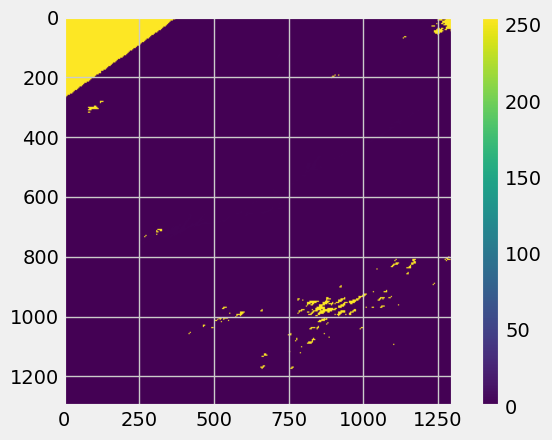

In [47]:
plt.imshow(raster_qad)
plt.colorbar()

### Output predicted raster to GeoTiff
We can then output our raster array into GeoTiff file for further analysis. We can produce Cloud Optimized GeoTiff (COG) files in this step by simply change the GTiff driver to COG

Below code creates and save GeoTiff raster file with geospatial reference information
1. Geotransform paramters
    1. geoTransform = (-9961223.407, 231.65635, 0.0, 4285642.633667, 0.0, -231.65635)
    2. -9961223.407 -- X-coordinate of upper-left corner
    3. 


In [48]:
geoTransform = (-9961223.407, 231.65635, 0.0, 4285642.633667, 0.0, -231.65635)
predictedPath = "PowellPredictedWaterMask.tif"
driver = gdal.GetDriverByName("GTiff")
outDs = driver.Create(predictedPath, 1300, 1300, 1, gdal.GDT_Int16, options=['COMPRESS=LZW'])
outDs.SetGeoTransform(geoTransform)
outDs.SetProjection(rasterProjection)
outBand = outDs.GetRasterBand(1)
outBand.WriteArray(raster_qad)
outBand.SetNoDataValue(255)
outDs.FlushCache()
outDs = None
outBand = None
driver = None 


In [49]:
mask_3857 = folium_helper.reproject_to_3857(predictedPath)
mask_d = folium_helper.get_bounds(mask_3857)
mask_b1 = folium_helper.open_and_get_band(mask_3857, 1)
folium_helper.cleanup(mask_3857)
mask_b1 = np.where(mask_b1 == 255, 0, mask_b1)
zeros = np.zeros_like(mask_b1)
mask_rgb = np.dstack((mask_b1, zeros, zeros))

Transform: | 491.82, 0.00,-12749861.52|
| 0.00,-491.82, 4656230.30|
| 0.00, 0.00, 1.00|
Width: 1670 Height: 770


In [51]:
m = folium.Map(location=[mask_d['center'][1], mask_d['center'][0]],
                   tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}', zoom_start = 6, attr='Google')


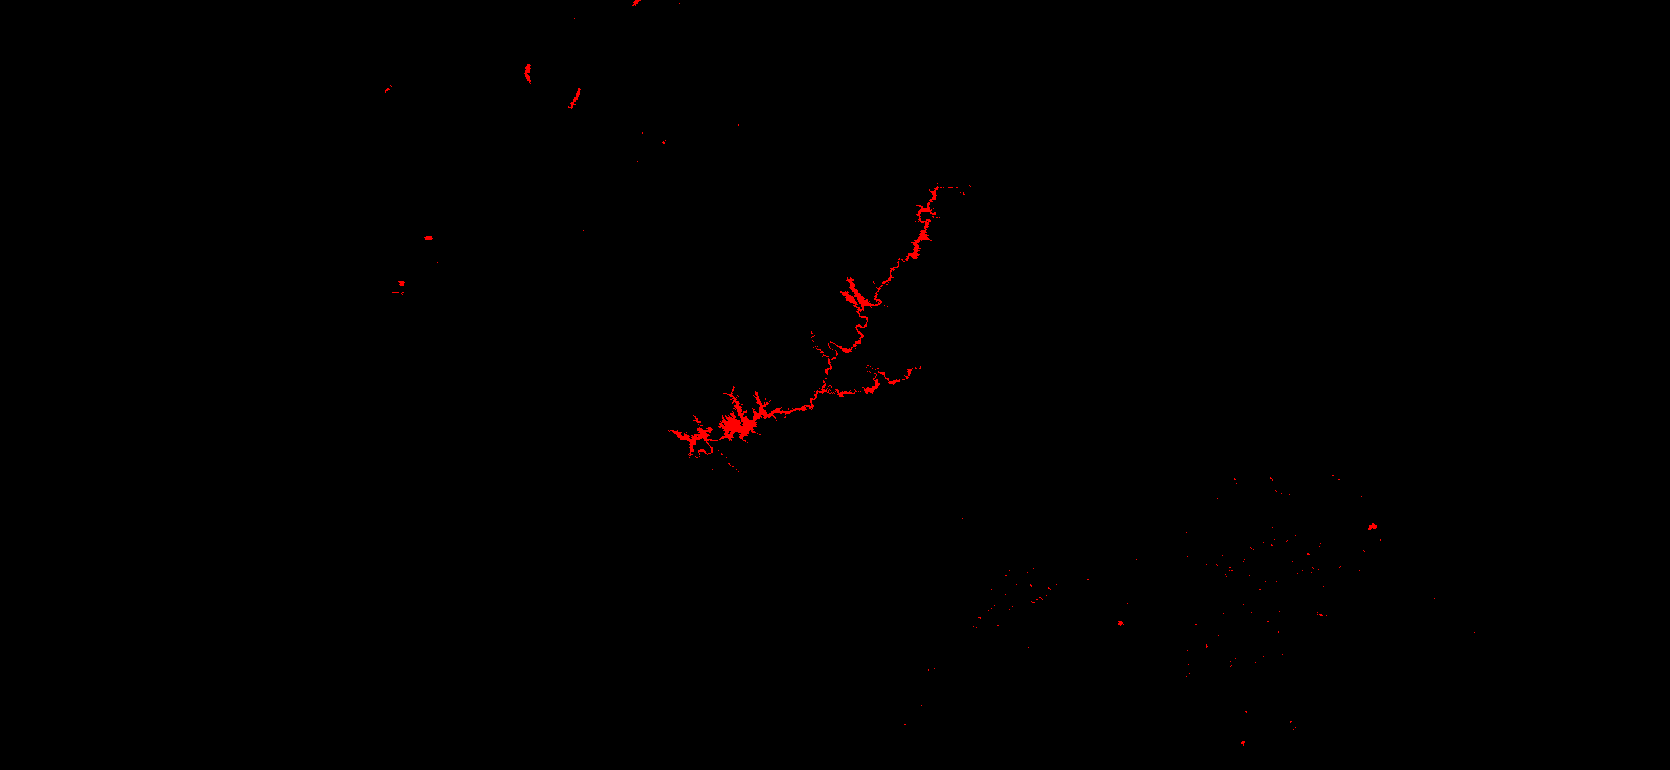
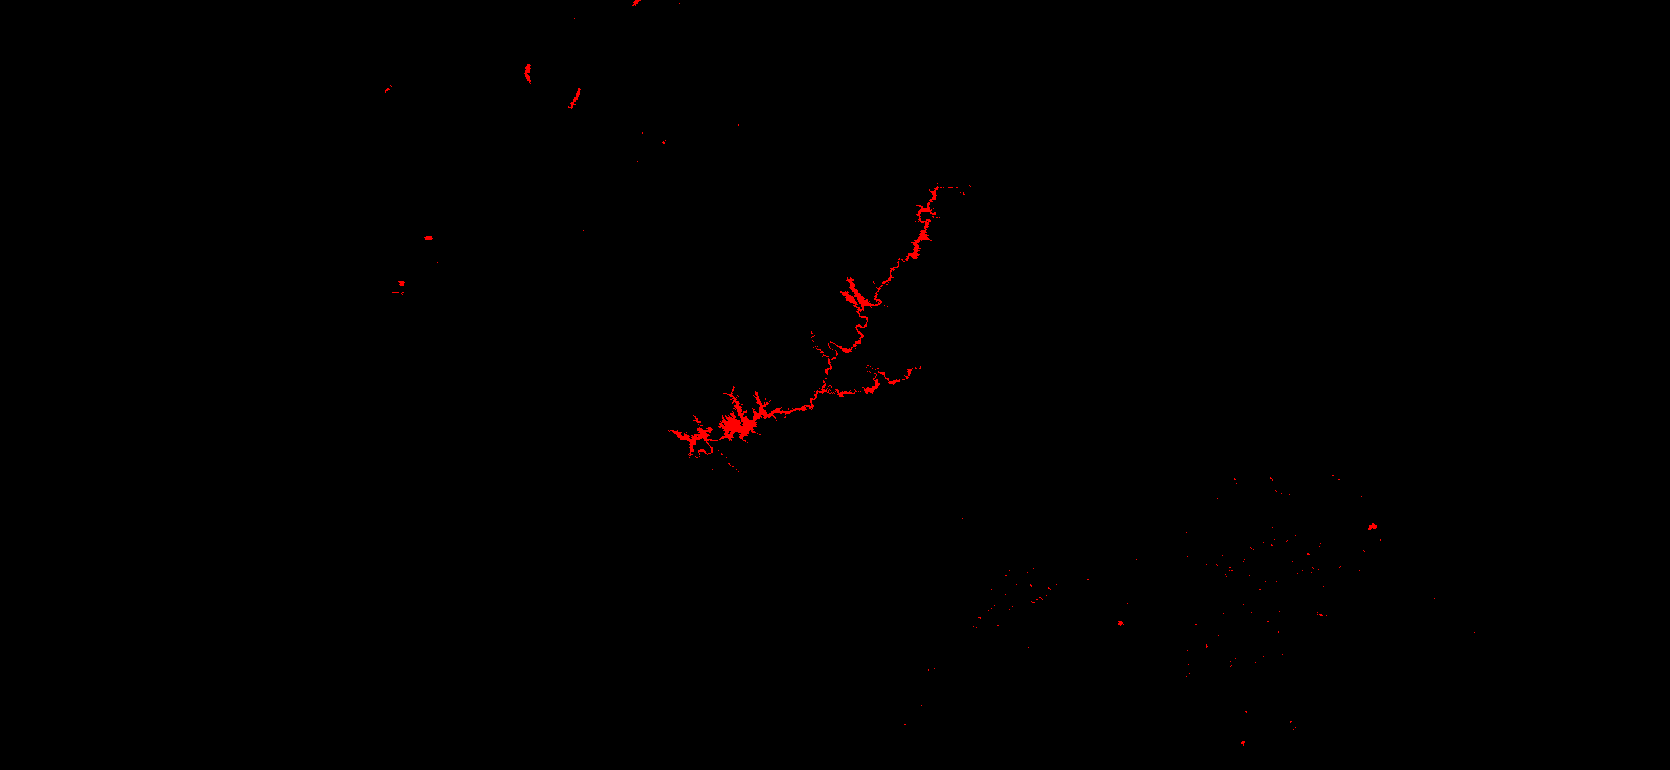
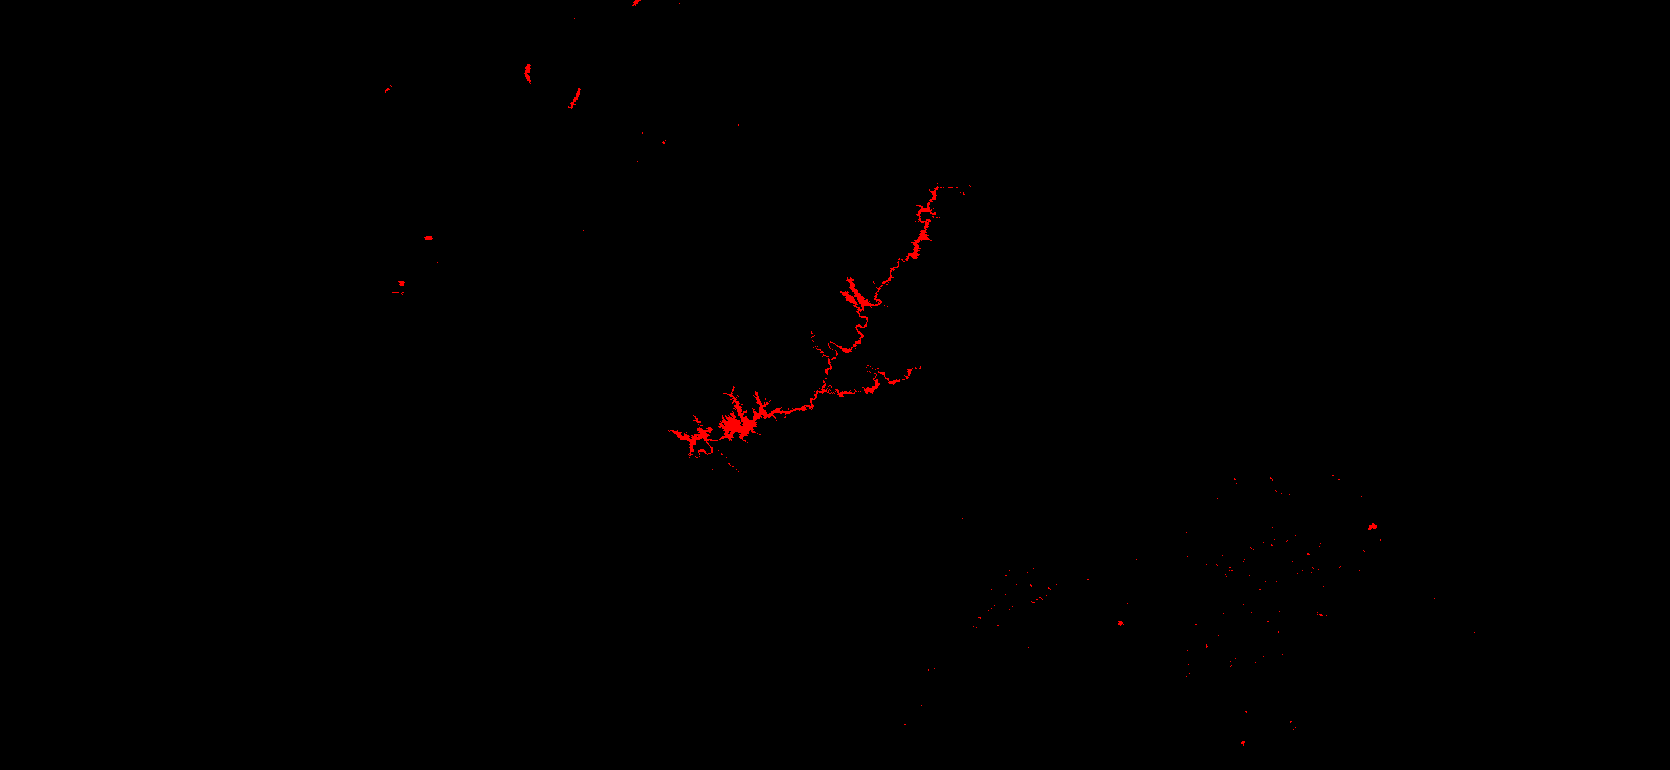
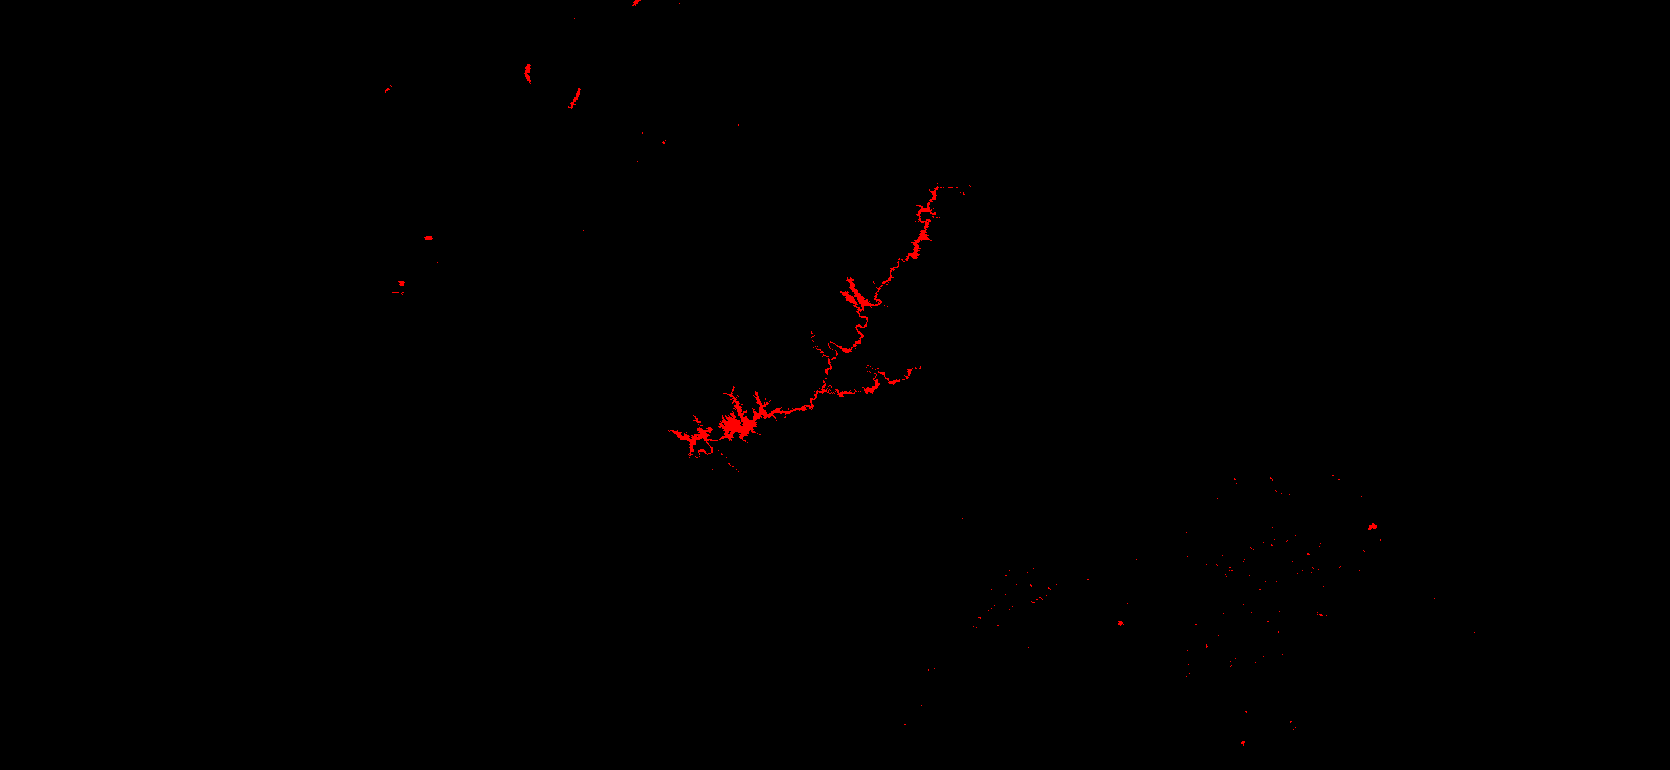
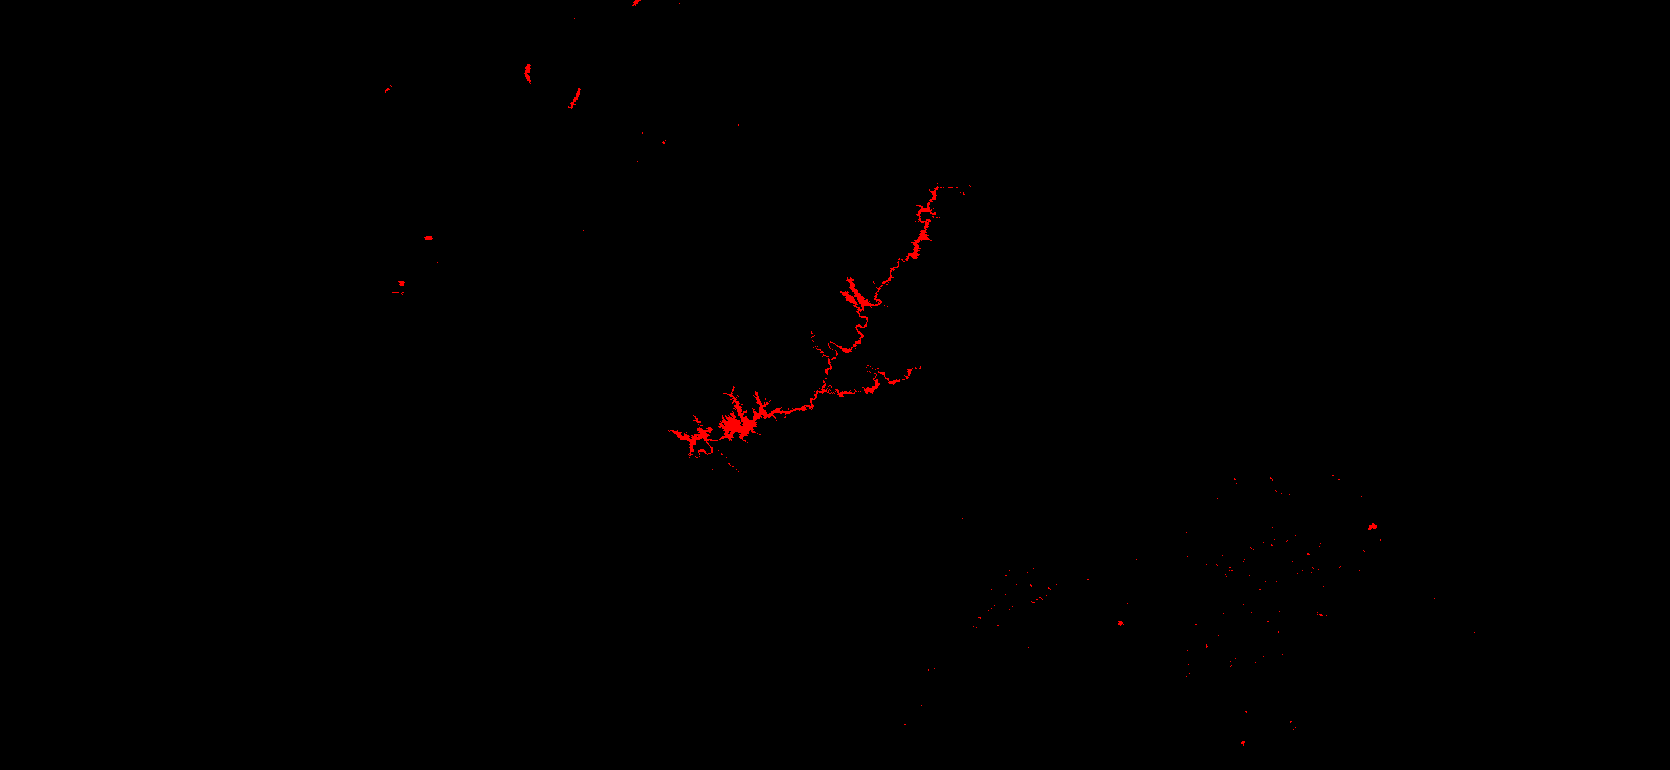
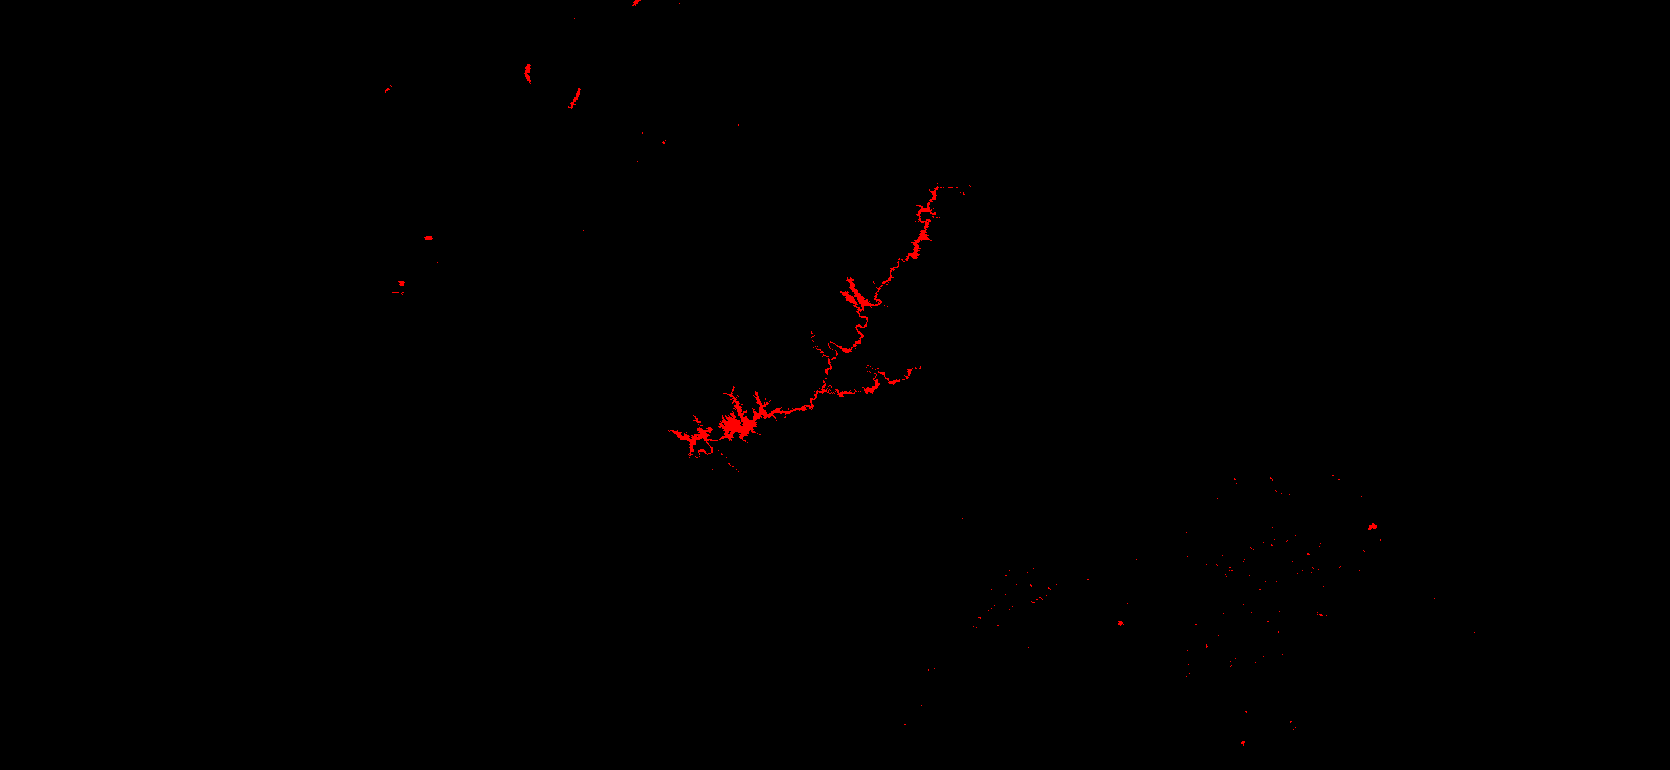

In [57]:
m.add_child(folium_helper.get_overlay(mask_rgb, mask_d, 'Water classification RF predicted mask', opacity=0.6))
m.add_child(plugins.MousePosition())
m.add_child(folium.LayerControl())